In [1]:
import os
import sys
from pathlib import Path

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = '/content/drive/Othercomputers/Lenovo L15/Desktop/repo_collabs/ds_projects_collabs/2-nlp-astroturfing-report'
    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)

    # For Colab, manually upload your service account JSON to the ephemeral /content/ folder
    # This secures your key without syncing it to Google Drive!
    try:
        from google.colab import userdata
        os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = userdata.get('GCP_JSON_PATH')
        os.environ['GCP_PROJECT_ID'] = userdata.get('GCP_PROJECT_ID')
    except Exception:
        print('Please open the Colab Secrets (Key Icon) and add:')
        print('- GCP_PROJECT_ID : your project id')
        print('- GCP_JSON_PATH : /content/your_service_account.json')
        print('Remember to upload the actual .json file physically to the /content/ folder every time you start a new session!')
        os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = input('Path to uploaded JSON: ')
        os.environ['GCP_PROJECT_ID'] = input('GCP Project ID: ')
else:
    # Running locally in VS Code
    current_dir = Path().absolute()
    project_root = current_dir.parent
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))



In [2]:
os.environ['GCP_PROJECT_ID'] = 'astroturfing-report'
os.environ['GCP_DATASET_ID'] = 'reddit_scrap'
project_id = os.environ.get('GCP_PROJECT_ID')
dataset_id = os.environ.get('GCP_DATASET_ID')
print(f"Working with Project: {project_id}, Dataset: {dataset_id}")

Working with Project: astroturfing-report, Dataset: reddit_scrap


In [3]:
# Run this ONCE if executing in Google Colab to install heavy dependencies
import sys
if 'google.colab' in sys.modules:
    !pip install -r requirements.txt
else:
    print('Running locally. Assuming requirements are already installed.')


Running locally. Assuming requirements are already installed.


# Imports
All third-party libraries and local modules used in this notebook.

In [4]:
import os
import sys
import pandas as pd
from google.cloud import bigquery
from loguru import logger

# Project Modules
from src.forensics.manual_scrapping import scrape_submission_url
from src.infra.data_transformation import transform_to_structured
from src.infra.gcp_ingestion import load_to_bigquery
from src.infra.run_transformations import run_all_transformations
from src.nlp.nlp_pipeline import run_nlp_pipeline
from src.visualization.plots import generate_all_plots


# Pipeline Control Notebook
Use these interactive cells to run the Scraping, Transformation, and Ingestion stages manually.


In [ ]:
!pip install -r requirements.txt

# Phase 1. Scrapping and GCP upload.

## 1. Scrape a Reddit Thread
Replace the URL below with the submission you want to scrape.

In [ ]:
## WARNING this will take time, 1 sec per user scrapped from the URL used. ##
TARGET_URL = "https://www.reddit.com/r/mexico/comments/1rcb63u/i_hope_you_win_your_fight_against_the_cartel/" # Example URL

print(f"Starting manual scrape for: {TARGET_URL}")
raw_file_path = scrape_submission_url(TARGET_URL)

if raw_file_path:
    print(f"Scraping complete. Raw file saved at: {raw_file_path}")
else:
    print("Scraping failed.")


## 2. Transform Phase
Define your mode:
- `master`: Transforms all JSONs into a single master CSV (replaces BigQuery table entirely).
- `single`: Transforms only the latest raw file (appends to BigQuery table).

In [ ]:
MODE = "single"
print(f"Starting transformation in {MODE} mode...")

if MODE == "master":
    print("Consolidating all raw data into master CSV...")
    structured_file = transform_to_structured(
        input_path="data/raw",
        output_dir="data/structured",
        format="csv"
    )
    write_disposition = "WRITE_TRUNCATE"
else:
    print(f"Transforming single submission: {raw_file_path}")
    structured_file = transform_to_structured(
        input_path=raw_file_path,
        output_dir="data/structured",
        format="csv"
    )
    write_disposition = "WRITE_APPEND"

if structured_file:
    print(f"Transformation complete. Structured file ready at: {structured_file}")
else:
    print("Transformation failed.")


## 3. Ingestion Phase
Push the structured data to BigQuery.

In [ ]:
# Set the file to upload. To use an existing file instead of the pipeline output, edit these variables:
try:
    file_to_upload = structured_file
    current_write_disposition = write_disposition
except NameError:
    file_to_upload = r'C:\Users\arq_c\Desktop\repo_collabs\ds_projects_collabs\2-nlp-astroturfing-report\data\structured\transformed_comments.csv'
    current_write_disposition = 'WRITE_APPEND'

print(f"Syncing {file_to_upload} to BigQuery...")
print(f"Table operation mode: {current_write_disposition}")

try:
    load_to_bigquery(
        file_path=file_to_upload,
        table_name="comments_structured",
        write_disposition=current_write_disposition
    )
    print("Ingestion complete. Data is now in GCP.")
except Exception as e:
    print(f"Ingestion failed: {e}")


# Phase 2: Run GCP Transformations (Medallion Architecture)


## 1. BigQuery SQL implementations.
Executes the Bronze -> Silver -> Gold SQL pipelines in BigQuery.

In [13]:

print("Starting GCP SQL Transformations...")
try:
    run_all_transformations()
    print("Transformations completed successfully!")
except Exception as e:
    print(f"Transformation failed: {e}")


Starting GCP SQL Transformations...
Transformation failed: replace() argument 2 must be str, not None


# Phase 3: NLP Processing (Colab Mode)
This phase will pull data from the BigQuery `gold_nlp` table, run heavy BERT Embeddings and Clustering, perform Sentiment Analysis, and push the results back to a new `gold_nlp_results` table.

In [5]:
from src.nlp.data_loader import pull_gold_nlp

# Download the data you already scrapped and pushed to BigQuery
data_df = pull_gold_nlp()
print(f"Loaded {len(data_df)} records for NLP processing.")


2026-03-03 21:17:03.737 | INFO     | src.nlp.data_loader:pull_gold_nlp:18 - Downloading NLP input data from reddit_scrap.gold_nlp...
2026-03-03 21:17:05.950 | SUCCESS  | src.nlp.data_loader:pull_gold_nlp:20 - Downloaded 189 records.


Loaded 189 records for NLP processing.


In [6]:

print("Initializing NLP Pipeline... This may take several minutes on the first run as models download.")
run_nlp_pipeline()


2026-03-03 21:17:08.195 | INFO     | src.nlp.nlp_pipeline:run_nlp_pipeline:7 - === Starting Phase 2: NLP Pipeline ===
2026-03-03 21:17:08.204 | INFO     | src.nlp.data_loader:pull_gold_nlp:18 - Downloading NLP input data from reddit_scrap.gold_nlp...


Initializing NLP Pipeline... This may take several minutes on the first run as models download.


2026-03-03 21:17:10.142 | SUCCESS  | src.nlp.data_loader:pull_gold_nlp:20 - Downloaded 189 records.
2026-03-03 21:17:10.143 | INFO     | src.nlp.embeddings_cluster:generate_clusters:9 - Loading multilingual embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-03 21:17:14.666 | INFO     | src.nlp.embeddings_cluster:generate_clusters:13 - Generating embeddings...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

2026-03-03 21:17:17.766 | INFO     | src.nlp.embeddings_cluster:generate_clusters:16 - Reducing dimensionality with UMAP...
/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-03-03 21:17:29.439 | INFO     | src.nlp.embeddings_cluster:generate_clusters:20 - Clustering with HDBSCAN...
2026-03-03 21:17:29.449 | SUCCESS  | src.nlp.embeddings_cluster:generate_clusters:28 - Found 2 clusters (excluding noise -1).
2026-03-03 21:17:29.450 | INFO     | src.nlp.sentiment_analysis:analyze_sentiment:7 - Loading multilingual sentiment model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-03 21:17:32.121 | INFO     | src.nlp.sentiment_analysis:analyze_sentiment:11 - Running sentiment analysis...
2026-03-03 21:18:09.632 | SUCCESS  | src.nlp.sentiment_analysis:analyze_sentiment:18 - Sentiment analysis complete.
2026-03-03 21:18:09.966 | INFO     | src.nlp.data_loader:push_nlp_results:30 - Uploading NLP results to astroturfing-report.reddit_scrap.gold_nlp_results...
2026-03-03 21:18:14.948 | SUCCESS  | src.nlp.data_loader:push_nlp_results:33 - Upload complete.


# Phase 4: Data Visualization & Reporting
This phase will synthesize our raw metadata, derived trust scores, and deep NLP results (clusters/sentiment) into a final, unified presentation layer. It will build the unified `gold_reporting_view` in BigQuery and generate local matplotlib visualiztions.

2026-03-03 21:22:01.665 | INFO     | __main__:<module>:10 - Building final reporting view in BigQuery...
2026-03-03 21:22:02.789 | SUCCESS  | __main__:<module>:14 - Success! `gold_reporting_view` is now available in BigQuery for Tableau/Looker Studio.
2026-03-03 21:22:02.790 | INFO     | __main__:<module>:17 - Downloading unified dataset for Python visualizations...
2026-03-03 21:22:05.182 | SUCCESS  | __main__:<module>:21 - Generating visualizations for 192 records...
2026-03-03 21:22:05.214 | INFO     | src.visualization.plots:print_cluster_narratives:73 - Extracting narrative samples for each cluster...
2026-03-03 21:22:05.326 | INFO     | src.visualization.plots:plot_astroturfing_quadrant:100 - Plotting Astroturfing Quadrant...



CLUSTER NARRATIVE EXAMPLES

[Noise (Organic): Uncoordinated Chatter]
  - This changes nothing. Including how much you play call of duty....
  - No hay ganadores en esta batalla...
  - f\*ck off, who sells them fucking ROCKET LAUNCHERS????...

[Narrative 0 (giphy, thank, hope): Coordinated Narrative / Copypasta]
  - Tesekur ederim, brother. Gracias, we all hope so....
  - Lol...
  - Casa de cranka?...

[Narrative 1 (government, cartels, cartel): Coordinated Narrative / Copypasta]
  - Lo mas preocupante no solo es la erradicación de los carteles,tambien del gobierno que lo quieren ver el país hundido...
  - El problema de México es el drogadicto vecino que tenemos, la pelea no es solo son los de aquí de México, si no los del ...
  - Wouldn't they just become legal distributors , they would gladly exchange having to hire so much security for a tax

Edi...




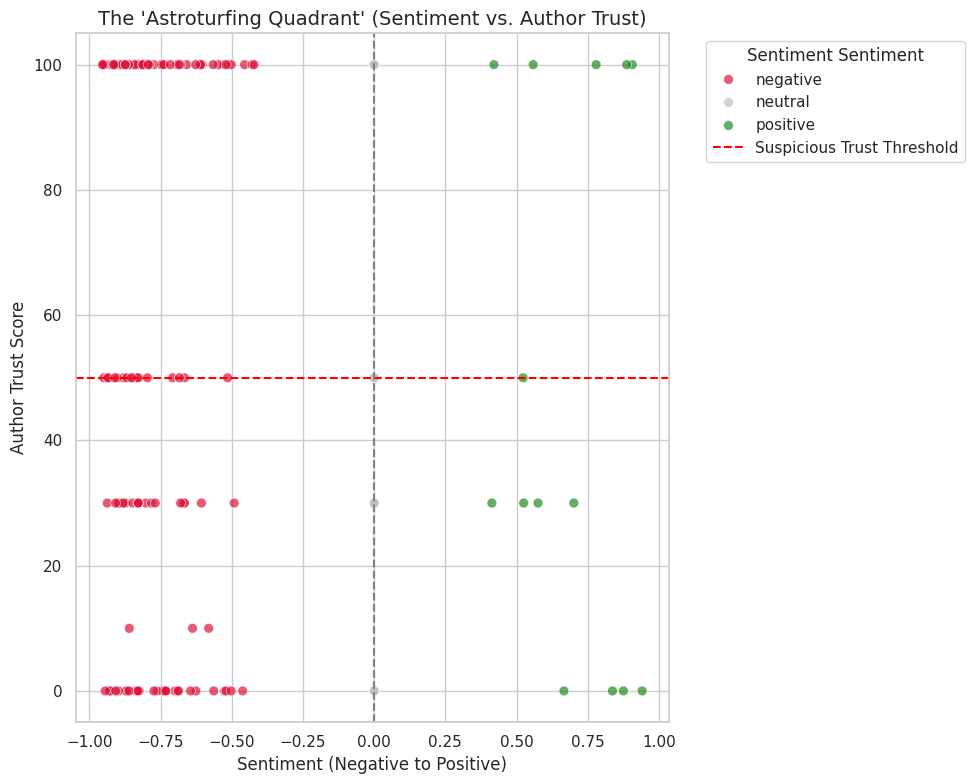

2026-03-03 21:22:06.150 | INFO     | src.visualization.plots:plot_narrative_timeline:119 - Plotting Narrative Timeline...


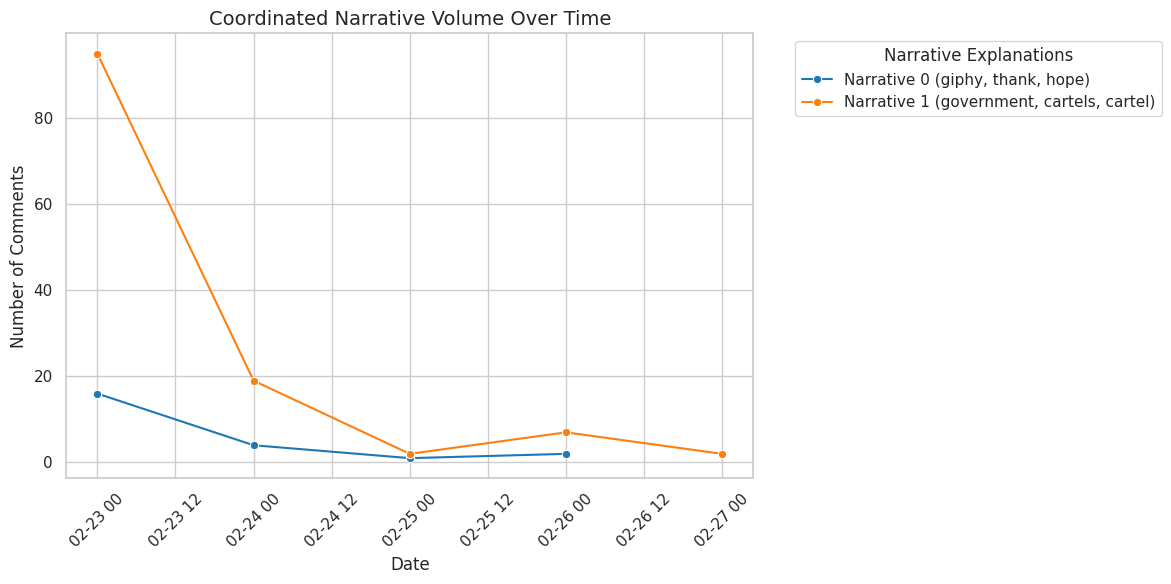

2026-03-03 21:22:06.615 | INFO     | src.visualization.plots:plot_kde_density:142 - Plotting KDE Density Map...


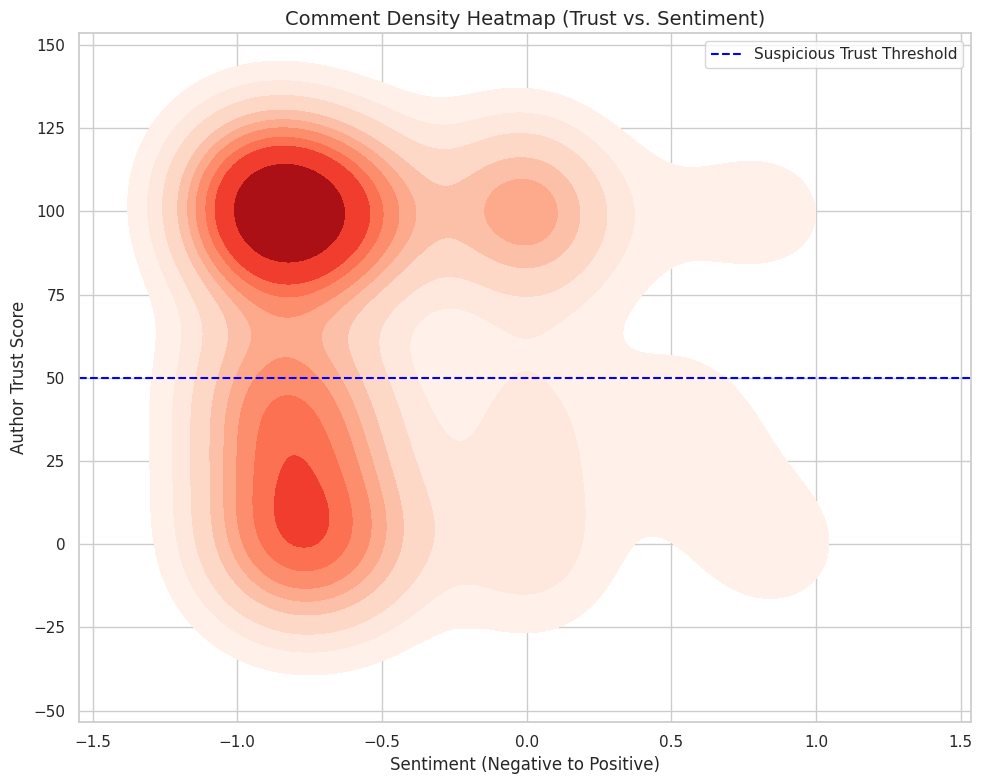

2026-03-03 21:22:07.222 | INFO     | src.visualization.plots:plot_trust_wordclouds:158 - Plotting Word Clouds...


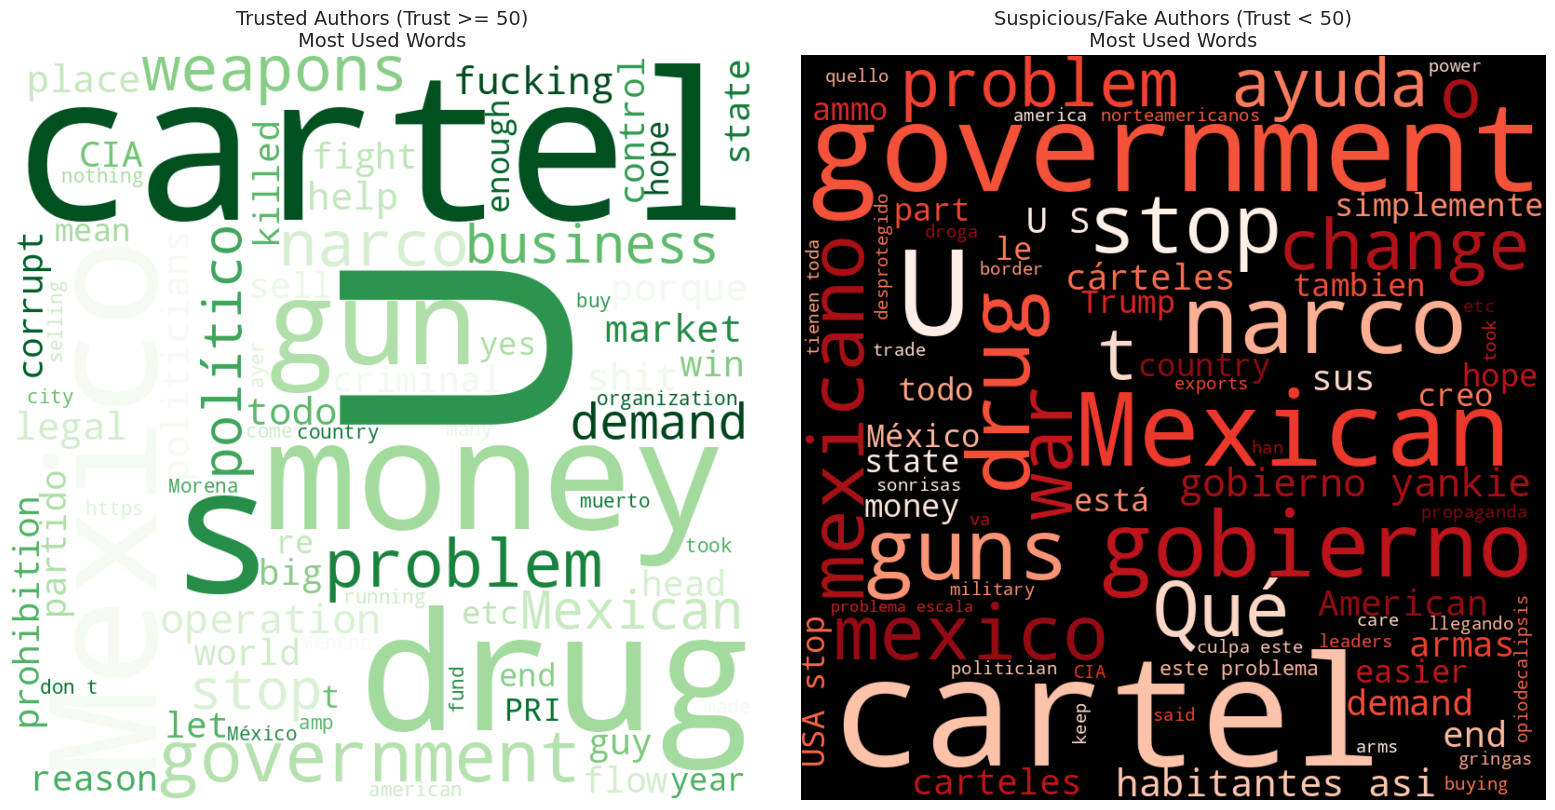

2026-03-03 21:22:09.216 | INFO     | src.visualization.plots:plot_trust_vs_sentiment:8 - Plotting Trust vs. Sentiment Distribution...
/home/jupyter/ds_projects_collabs/2-nlp-astroturfing-report/src/visualization/plots.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentiment_label', y='trust_score', palette='muted', inner='quartile')


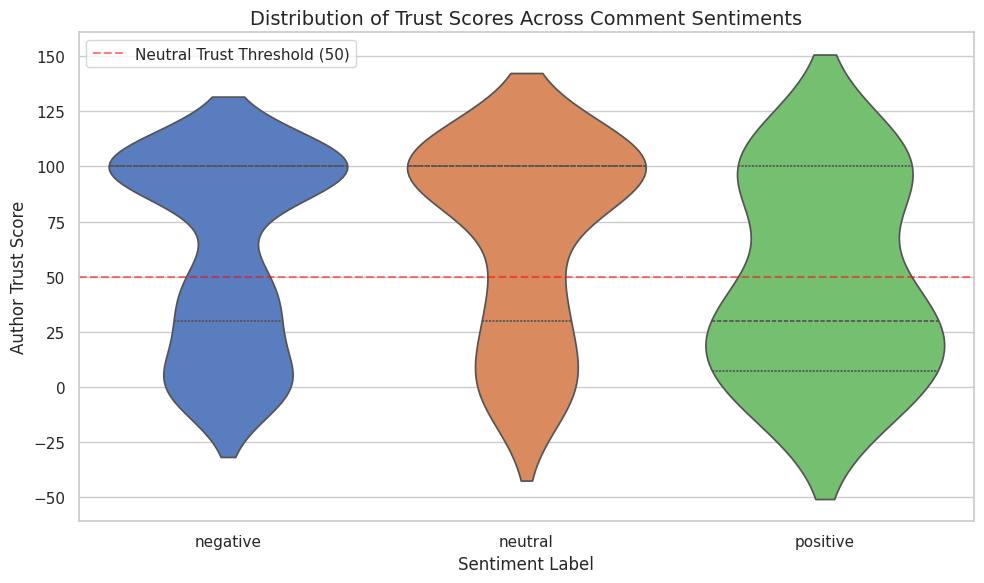

2026-03-03 21:22:10.225 | INFO     | src.visualization.plots:plot_umap_clusters:22 - Plotting UMAP clusters...


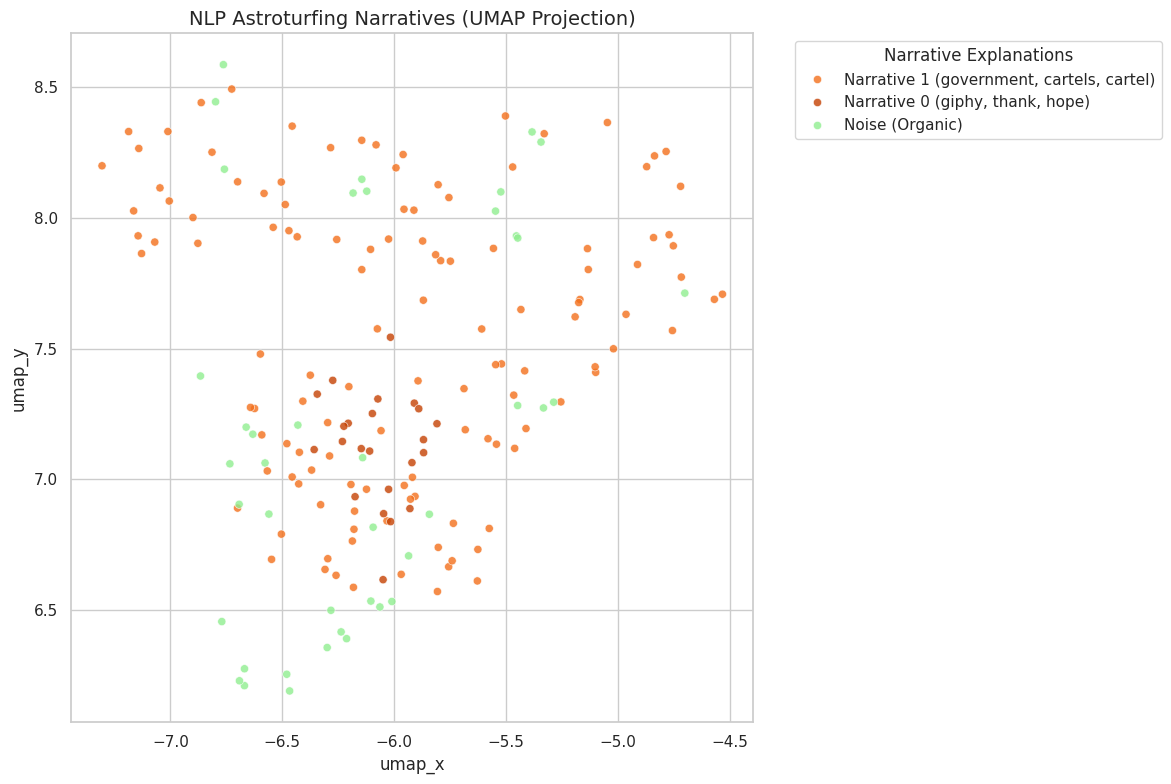

2026-03-03 21:22:10.481 | INFO     | src.visualization.plots:plot_cluster_breakdown:43 - Plotting Cluster Breakdown by Trust Score...
/home/jupyter/ds_projects_collabs/2-nlp-astroturfing-report/src/visualization/plots.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_trust, x='cluster_desc', y='trust_score', order=avg_trust['cluster_desc'], palette='YlOrBr')


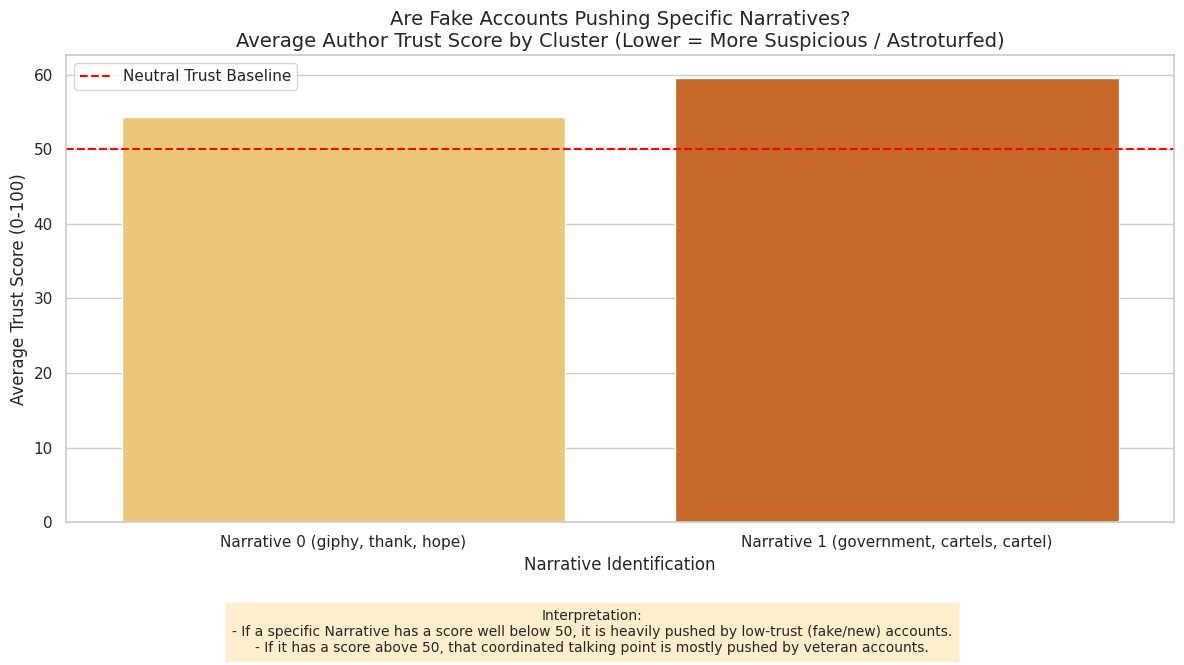

In [8]:
import os
import importlib
import src.visualization.plots

project_id = os.environ.get('GCP_PROJECT_ID')
dataset_id = os.environ.get('GCP_DATASET_ID', 'reddit_scrap')
client = bigquery.Client(project=project_id)

# 1. Create the unified gold_reporting_view in BigQuery
logger.info('Building final reporting view in BigQuery...')
with open('../src/bq_sql_transformations/05_gold_reporting.sql', 'r') as f:
    sql = f.read().replace('{{project_id}}', project_id).replace('{{dataset_id}}', dataset_id)
client.query(sql).result()
logger.success('Success! `gold_reporting_view` is now available in BigQuery for Tableau/Looker Studio.')

# 2. Download into Pandas for localized Python plotting
logger.info('Downloading unified dataset for Python visualizations...')
query = f"SELECT * FROM `{project_id}.{dataset_id}.gold_reporting_view`"
df = client.query(query).to_dataframe()

logger.success(f"Generating visualizations for {len(df)} records...")

# --- FORCE RELOAD THE PLOTS MODULE ---
importlib.reload(src.visualization.plots)
from src.visualization.plots import generate_all_plots

generate_all_plots(df)
